# 基于机器学习的贷款违约预测与客户风险分层分析

> **课程**：高级商务数据分析 | **数据来源**：天池金融风控贷款违约预测
> **技术栈**：pandas / numpy / matplotlib / seaborn / scikit-learn

## 0. 环境准备与库导入

In [1]:
# 0. 环境准备与库导入

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

# 中文字体 — seaborn 之后设，防止被覆盖
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 自动找到项目根目录
PROJECT_DIR = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(PROJECT_DIR, 'data', 'train.csv')):
        break
    PROJECT_DIR = os.path.dirname(PROJECT_DIR)

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
FIG_DIR = os.path.join(PROJECT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

print('ok 环境就绪')
print(f'项目根目录: {PROJECT_DIR}')
print('字体设置: ' + plt.rcParams['font.sans-serif'][0])

ok 环境就绪
项目根目录: C:\Users\14366\Desktop\高级商业数据分析
字体设置: Microsoft YaHei


## 1. 数据读取与初探

In [2]:
# 1.1 读取数据（只用训练集，抽3万条）

df_full = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
print(f'原始训练集: {df_full.shape[0]:,} 行, {df_full.shape[1]} 列')

# 分层抽样3万条，保持违约比例不变
df = df_full.sample(n=30000, random_state=42).reset_index(drop=True)
print(f'抽样后: {df.shape[0]:,} 行')

原始训练集: 800,000 行, 47 列
抽样后: 30,000 行


In [3]:
# 1.2 前5行
df.head()

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
0,212188,4300.0,3,16.99,153.29,D,D3,54.0,NaN,1,...,3.0,9.0,3.0,6.0,2.0,3.0,0.0,0.0,0.0,3.0
1,299036,28000.0,3,5.32,843.22,A,A1,160.0,10+ years,0,...,8.0,23.0,8.0,19.0,3.0,11.0,0.0,0.0,0.0,0.0
2,475978,13000.0,3,17.57,467.19,D,D4,6426.0,10+ years,0,...,10.0,21.0,9.0,15.0,6.0,18.0,0.0,0.0,0.0,5.0
3,588988,10000.0,3,7.59,311.48,A,A3,62512.0,3 years,1,...,4.0,4.0,6.0,8.0,5.0,6.0,0.0,0.0,0.0,1.0
4,138859,7000.0,3,10.08,226.14,B,B1,118.0,4 years,0,...,4.0,11.0,5.0,12.0,2.0,9.0,0.0,0.0,0.0,1.0


In [4]:
# 1.3 列名与类型
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  30000 non-null  int64  
 1   loanAmnt            30000 non-null  float64
 2   term                30000 non-null  int64  
 3   interestRate        30000 non-null  float64
 4   installment         30000 non-null  float64
 5   grade               30000 non-null  str    
 6   subGrade            30000 non-null  str    
 7   employmentTitle     30000 non-null  float64
 8   employmentLength    28252 non-null  str    
 9   homeOwnership       30000 non-null  int64  
 10  annualIncome        30000 non-null  float64
 11  verificationStatus  30000 non-null  int64  
 12  issueDate           30000 non-null  str    
 13  isDefault           30000 non-null  int64  
 14  purpose             30000 non-null  int64  
 15  postCode            30000 non-null  float64
 16  regionCode     

In [5]:
# 1.4 描述性统计
df.describe().round(2)

,id,loanAmnt,term,interestRate,installment,employmentTitle,homeOwnership,annualIncome,verificationStatus,isDefault,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.0,...,28465.00,28465.00,28465.00,28465.00,28465.00,28740.00,27378.00,28465.00,28465.00,28465.00
mean,401851.58,14365.05,3.48,13.23,437.01,72471.33,0.61,75976.59,1.01,0.2,...,8.18,8.56,8.27,14.67,5.58,11.64,0.00,0.00,0.09,2.17
std,230689.33,8711.85,0.85,4.76,261.94,106849.01,0.67,52893.34,0.79,0.4,...,4.82,7.43,4.54,8.09,3.24,5.43,0.03,0.06,0.57,1.84
min,18.00,1000.00,3.00,5.31,22.79,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,203495.25,7843.75,3.00,9.75,247.93,427.00,0.00,45760.00,0.00,0.0,...,5.00,4.00,5.00,9.00,3.00,8.00,0.00,0.00,0.00,1.00
50%,402679.50,12000.00,3.00,12.74,372.40,7979.00,1.00,65000.00,1.00,0.0,...,7.00,7.00,7.00,13.00,5.00,11.00,0.00,0.00,0.00,2.00
75%,602701.25,20000.00,3.00,15.99,581.08,120596.75,1.00,90140.75,2.00,0.0,...,11.00,11.00,10.00,19.00,7.00,14.00,0.00,0.00,0.00,3.00
max,799997.00,40000.00,5.00,30.99,1546.52,378342.00,5.00,1800000.00,2.00,1.0,...,53.00,91.00,66.00,79.00,43.00,67.00,2.00,2.00,39.00,30.00


In [6]:
# 1.5 缺失值统计

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) == 0:
    print('无缺失值')
else:
    print(f'有缺失值的列 ({len(missing)} 个):')
    for col, cnt in missing.items():
        print(f'  {col}: {cnt} ({cnt/len(df)*100:.1f}%)')

有缺失值的列 (19 个):
  n11: 2622 (8.7%)
  employmentLength: 1748 (5.8%)
  n0: 1535 (5.1%)
  n13: 1535 (5.1%)
  n12: 1535 (5.1%)
  n2: 1535 (5.1%)
  n1: 1535 (5.1%)
  n6: 1535 (5.1%)
  n5: 1535 (5.1%)
  n7: 1535 (5.1%)
  n3: 1535 (5.1%)
  n14: 1535 (5.1%)
  n8: 1535 (5.1%)
  n9: 1535 (5.1%)
  n4: 1260 (4.2%)
  n10: 1260 (4.2%)
  revolUtil: 14 (0.0%)
  pubRecBankruptcies: 13 (0.0%)
  dti: 7 (0.0%)


In [7]:
# 1.6 目标变量分布

default_rate = df['isDefault'].mean() * 100
print(f'违约: {df["isDefault"].sum():,} ({default_rate:.1f}%)')
print(f'正常: {(df["isDefault"]==0).sum():,} ({100-default_rate:.1f}%)')

违约: 5,955 (19.9%)
正常: 24,045 (80.2%)


## 2. 数据预处理

In [8]:
# 2.1 缺失值处理
# employmentLength 缺失 → 填'未知'
# n0~n14 匿名特征缺失 → 填中位数（避免极端值影响）
# dti / pubRecBankruptcies / revolUtil 少量缺失 → 填中位数

df['employmentLength'] = df['employmentLength'].fillna('未知')

n_cols = [c for c in df.columns if c.startswith('n') and c[1:].isdigit()]
for col in n_cols:
    df[col] = df[col].fillna(df[col].median())

# 剩余少量缺失的数值列
for col in ['dti', 'pubRecBankruptcies', 'revolUtil']:
    df[col] = df[col].fillna(df[col].median())

print('employmentLength 填充为: 未知')
print(f'n0~n14 各列已用中位数填充')
print(f'dti / pubRecBankruptcies / revolUtil 已用中位数填充')
print(f'剩余缺失值: {df.isnull().sum().sum()}')

employmentLength 填充为: 未知
n0~n14 各列已用中位数填充
dti / pubRecBankruptcies / revolUtil 已用中位数填充
剩余缺失值: 0


In [9]:
# 2.2 分类变量整理

# grade / subGrade — 贷款等级，保留原值
# employmentLength — 含'< 1 year','1 year','10+ years'等，转为数字

emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10, '未知': -1
}
df['emp_length_num'] = df['employmentLength'].map(emp_map).fillna(-1).astype(int)

# homeOwnership — 0=租用, 1=自有, 2=抵押
# verificationStatus — 0=未验证, 1=已验证来源, 2=已核实
# 保持数值编码，加上标签

home_labels = {0: '租用', 1: '自有', 2: '抵押'}
df['home_label'] = df['homeOwnership'].map(home_labels)

print('employmentLength 数值化完成')
print(df['emp_length_num'].value_counts().sort_index())

employmentLength 数值化完成


emp_length_num
-1     1748
 0     2356
 1     1981
 2     2702
 3     2469
 4     1867
 5     1864
 6     1409
 7     1316
 8     1360
 9     1169
 10    9759
Name: count, dtype: int64


In [10]:
# 2.3 特征工程 — 构造衍生变量

# 月供收入比 = 分期金额 / (年收入/12)
df['install_income_ratio'] = df['installment'] / (df['annualIncome'] / 12)
df['install_income_ratio'] = df['install_income_ratio'].clip(upper=2.0)  # 截断极端值

# FICO 分均值
df['fico_mean'] = (df['ficoRangeLow'] + df['ficoRangeHigh']) / 2

# 负债覆盖比 = 年收入 / (贷款金额 * 利率)
df['income_debt_ratio'] = df['annualIncome'] / (df['loanAmnt'] * df['interestRate'] / 100 + 1)
df['income_debt_ratio'] = df['income_debt_ratio'].clip(upper=100)

# 信用历史长度（从 earliesCreditLine 提取年份，计算到2019年）
# earliesCreditLine 格式: 'Aug-2001'
df['credit_age'] = 2019 - pd.to_datetime(df['earliesCreditLine'], format='%b-%Y').dt.year

print('衍生变量: install_income_ratio, fico_mean, income_debt_ratio, credit_age')

衍生变量: install_income_ratio, fico_mean, income_debt_ratio, credit_age


In [11]:
# 2.3b 异常值处理
# dti 存在1条999%的极端错误值，用中位数替换
# annualIncome 极端值较多（最高180万），用99分位数截断

n_dti_bad = (df['dti'] > 200).sum()
df.loc[df['dti'] > 200, 'dti'] = df['dti'].median()
print(f'dti 极端值(>200%): {n_dti_bad} 条 → 已用中位数替换')

income_cap = df['annualIncome'].quantile(0.99)
n_income = (df['annualIncome'] > income_cap).sum()
df['annualIncome'] = df['annualIncome'].clip(upper=income_cap)
print(f'年收入 99分位截断值: {income_cap:,.0f} 美元, 截断 {n_income} 个极端值')

dti 极端值(>200%): 1 条 → 已用中位数替换
年收入 99分位截断值: 250,000 美元, 截断 283 个极端值


In [12]:
# 2.4 分类变量编码
# grade/subGrade 有序 → LabelEncoder
# regionCode/title 高基数无序 → LabelEncoder（树模型不在乎，OneHot会维度爆炸）
# purpose 无序14类 → OneHot（消除伪排序关系）

le_cols = ['grade', 'subGrade', 'regionCode', 'title']
for col in le_cols:
    df[col + '_enc'] = LabelEncoder().fit_transform(df[col].astype(str))

# purpose 单独做 OneHot
purpose_dummies = pd.get_dummies(df['purpose'], prefix='purpose', drop_first=True)
df = pd.concat([df, purpose_dummies], axis=1)

print(f'Label编码: {le_cols}')
print(f'purpose OneHot: {purpose_dummies.shape[1]} 列')

Label编码: ['grade', 'subGrade', 'regionCode', 'title']
purpose OneHot: 13 列


In [13]:
# 2.5 构建建模用特征集（排除ID、文本、日期列）

# 黑名单：这些列不参与建模
drop_cols = [
    'id',                   # 唯一标识，无预测价值
    'issueDate',            # 日期文字
    'employmentTitle',      # 原始职位（脱敏编码，高基数）
    'employmentLength',     # 原始工龄文字，已有 emp_length_num
    'earliesCreditLine',    # 日期文字，已有 credit_age
    'home_label',           # 中文标签，已有 homeOwnership 数值
    'grade', 'subGrade',    # 原始等级文字，已有 _enc 编码版
    'purpose',              # 原始用途文字，已有 OneHot 版（purpose_*）
    'regionCode', 'title',  # 原始类别文字，已有 _enc 编码版
    'postCode',             # 邮编，高基数低信息量
    'policyCode',           # 保单代码，几乎全为1
    'isDefault'             # 目标变量，单独存入 y
]

# 不在黑名单里的列，全部进入特征集
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()   # 特征矩阵
y = df['isDefault']           # 目标变量（0=正常 1=违约）

print(f'特征数: {X.shape[1]}, 目标: isDefault')

特征数: 56, 目标: isDefault


In [14]:
# 2.6 标准化

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f'标准化完成, {X_scaled.shape[1]} 个特征')

标准化完成, 56 个特征


## 3. 可视化

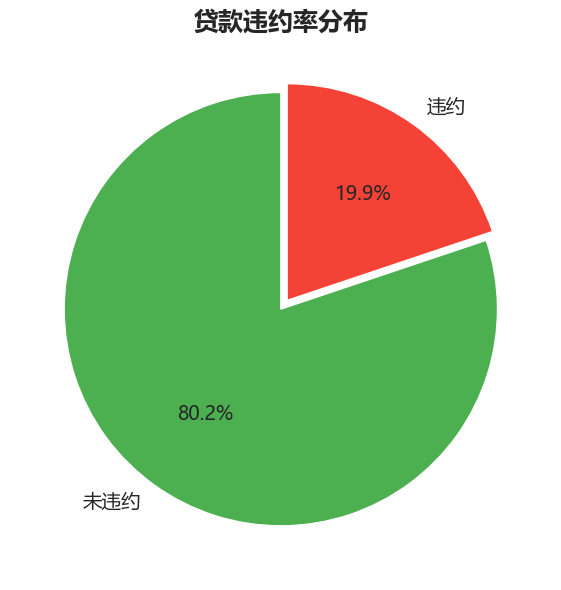

In [15]:
# 3.1 违约率饼图

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    [100-default_rate, default_rate],
    labels=['未违约','违约'],
    colors=['#4CAF50','#F44336'],
    autopct='%1.1f%%', startangle=90,
    explode=(0, 0.05), textprops={'fontsize': 14}
)
ax.set_title('贷款违约率分布', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_default_pie.png'), dpi=150, bbox_inches='tight')
plt.show()

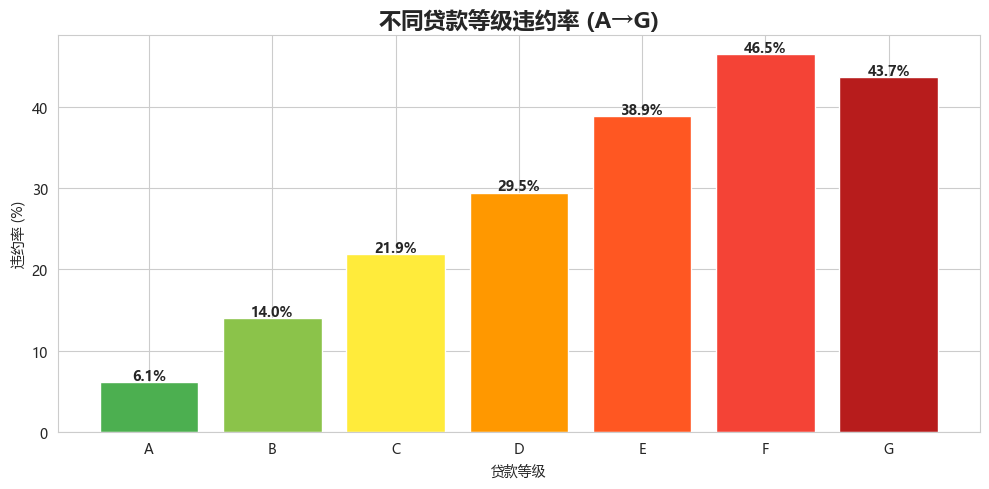

In [16]:
# 3.2 贷款等级违约率柱状图

grade_default = df.groupby('grade')['isDefault'].mean().sort_index() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50','#8BC34A','#FFEB3B','#FF9800','#FF5722','#F44336','#B71C1C']
ax.bar(grade_default.index, grade_default.values, color=colors[:len(grade_default)])
for i, v in enumerate(grade_default.values):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('不同贷款等级违约率 (A→G)', fontsize=16, fontweight='bold')
ax.set_xlabel('贷款等级'); ax.set_ylabel('违约率 (%)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_grade_default.png'), dpi=150, bbox_inches='tight')
plt.show()

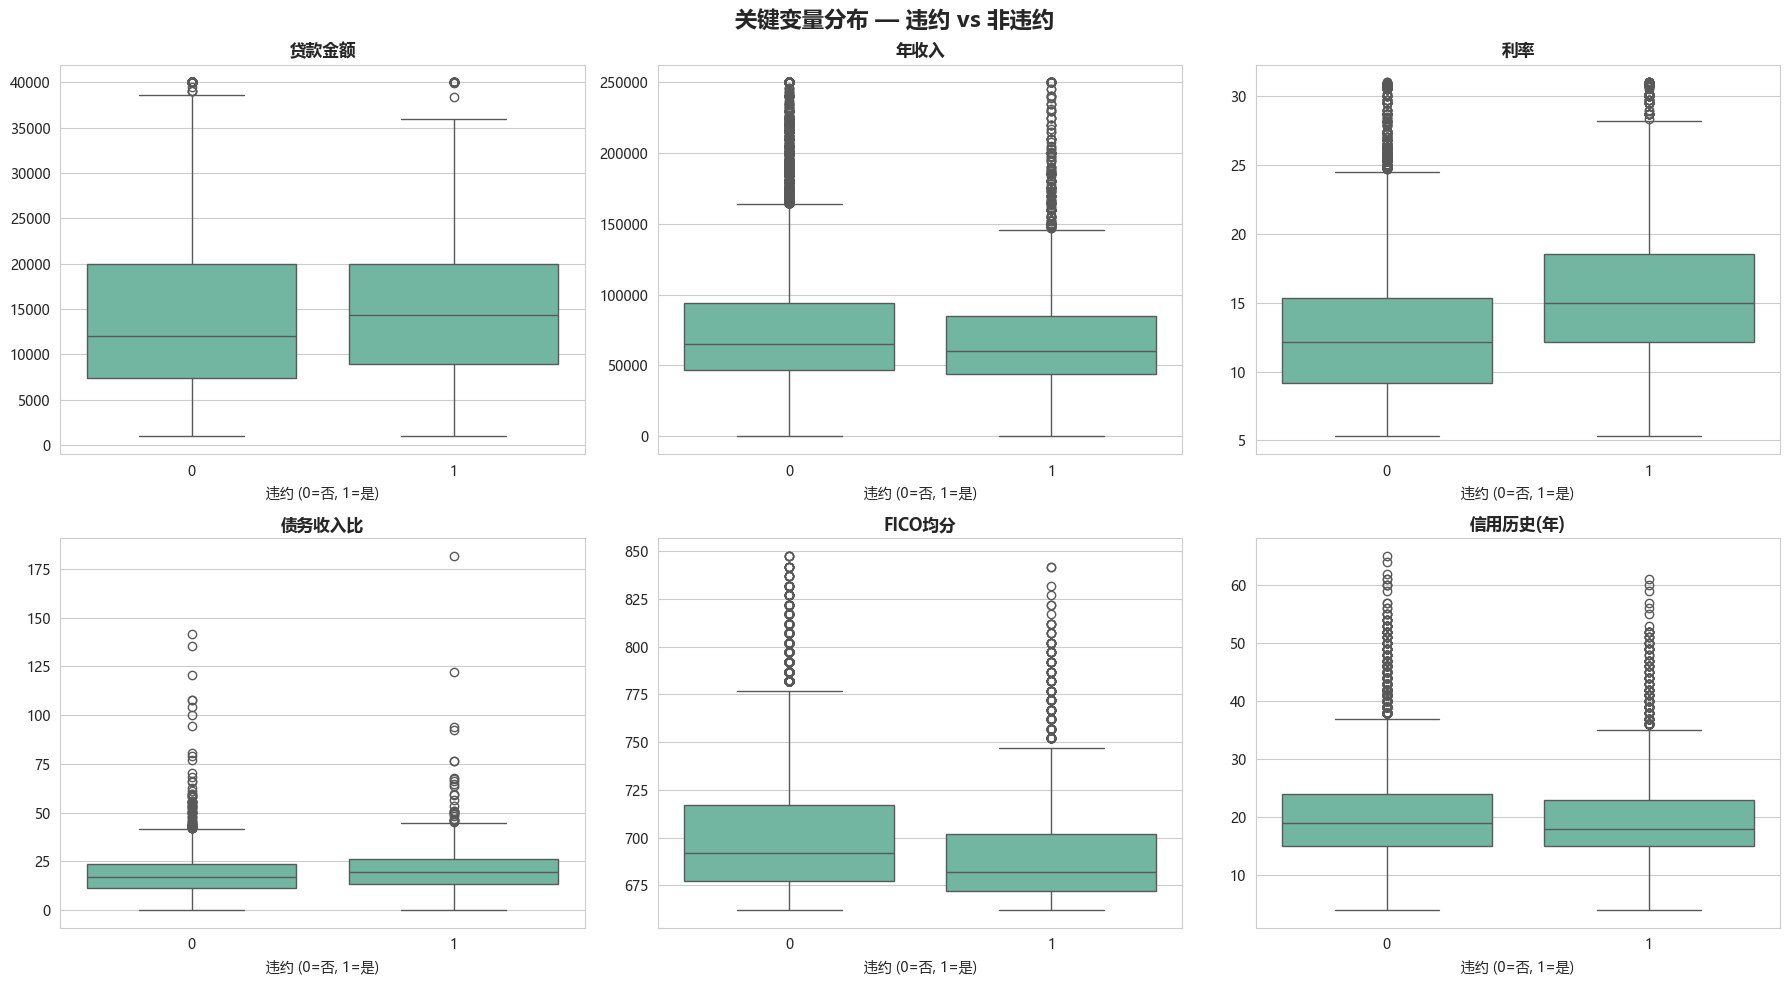

In [17]:
# 3.3 箱线图 — 关键变量按违约分组

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_vars = ['loanAmnt', 'annualIncome', 'interestRate', 'dti', 'fico_mean', 'credit_age']
titles = ['贷款金额', '年收入', '利率', '债务收入比', 'FICO均分', '信用历史(年)']

for i, (var, title) in enumerate(zip(plot_vars, titles)):
    ax = axes[i//3, i%3]
    sns.boxplot(x='isDefault', y=var, data=df, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('违约 (0=否, 1=是)')
    ax.set_ylabel('')

fig.suptitle('关键变量分布 — 违约 vs 非违约', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

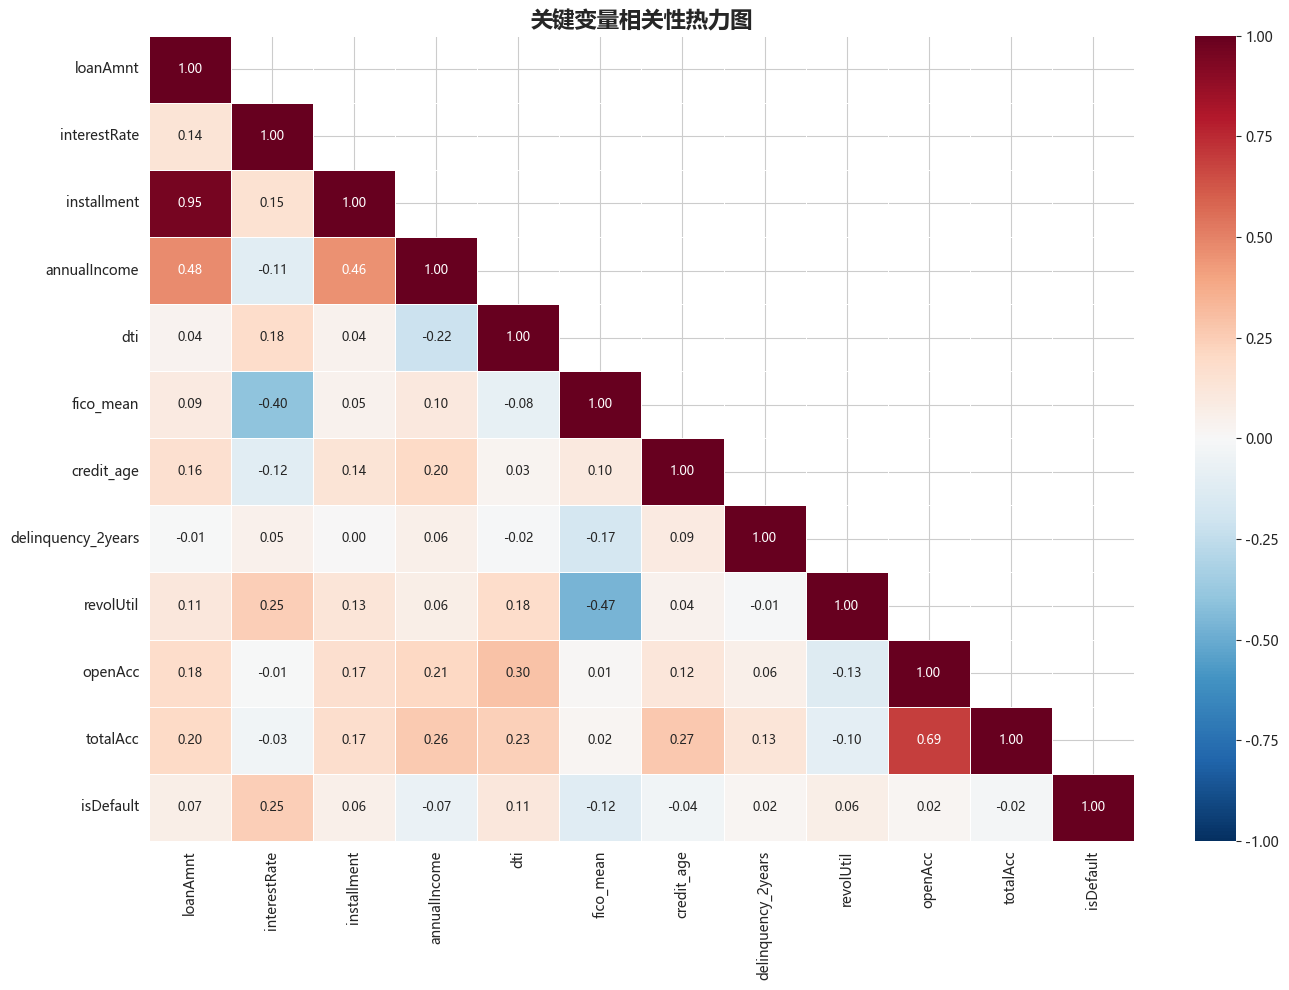

In [18]:
# 3.4 相关性热力图

corr_vars = ['loanAmnt','interestRate','installment','annualIncome',
             'dti','fico_mean','credit_age','delinquency_2years',
             'revolUtil','openAcc','totalAcc','isDefault']
corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'fontsize': 9})
ax.set_title('关键变量相关性热力图', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

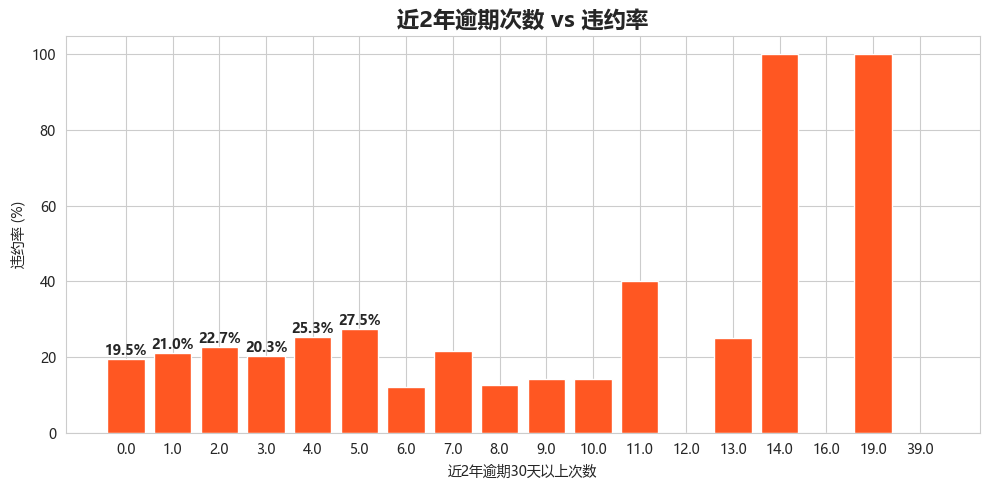

In [19]:
# 3.5 逾期次数 vs 违约率

delinq_default = df.groupby('delinquency_2years')['isDefault'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(delinq_default.index.astype(str), delinq_default.values, color='#FF5722')
for i, v in enumerate(delinq_default.values):
    if delinq_default.index[i] <= 5:
        ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('近2年逾期次数 vs 违约率', fontsize=16, fontweight='bold')
ax.set_xlabel('近2年逾期30天以上次数'); ax.set_ylabel('违约率 (%)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_delinquency.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. 导出清洗数据

In [20]:
# 4.1 保存清洗后数据

# 带标签的数据（Tableau用）
df.to_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'), index=False)
print(f'cleaned_data.csv: {df.shape}')

# 标准化特征 + 目标（建模用）
X_scaled['isDefault'] = y.values
X_scaled.to_csv(os.path.join(DATA_DIR, 'model_ready_data.csv'), index=False)
print(f'model_ready_data.csv: {X_scaled.shape}')

cleaned_data.csv: (30000, 70)


model_ready_data.csv: (30000, 57)


## 5. 阶段一完成

| 任务 | 状态 |
|:---|---:|
| 数据读取 | done |
| 缺失值处理 | done |
| 异常值处理 | done |
| 特征工程 | done |
| 标签编码 + 标准化 | done |
| 5张可视化图表 | done |
| 导出清洗数据 | done |

**产出**: `data/cleaned_data.csv` + `data/model_ready_data.csv` + `figures/fig1~5.png`

**下一步**: 阶段二 — 逻辑回归 + 随机森林 + XGBoost + 特征重要性 + 四象限矩阵

## 阶段二：建模分析

In [21]:
# 训练/测试集划分（7:3，分层抽样）
X_model = X_scaled.drop(columns=["isDefault"])
y_model = y

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.3, random_state=42, stratify=y_model
)

print(f"训练集: {X_train.shape[0]:,} 条, 测试集: {X_test.shape[0]:,} 条")
print(f"训练集违约率: {y_train.mean()*100:.1f}%, 测试集违约率: {y_test.mean()*100:.1f}%")

训练集: 21,000 条, 测试集: 9,000 条
训练集违约率: 19.9%, 测试集违约率: 19.8%


In [22]:
# 导入建模库
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

### 逻辑回归（基线模型）

In [23]:
# 逻辑回归（基线模型）
lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("逻辑回归 — 评估结果")
print("=" * 50)
print(f"准确率: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred_lr, target_names=["正常", "违约"]))
print("混淆矩阵:")
print(confusion_matrix(y_test, y_pred_lr))

逻辑回归 — 评估结果
准确率: 0.6572
AUC: 0.7027

分类报告:
              precision    recall  f1-score   support

          正常       0.88      0.66      0.76      7214
          违约       0.32      0.63      0.42      1786

    accuracy                           0.66      9000
   macro avg       0.60      0.65      0.59      9000
weighted avg       0.77      0.66      0.69      9000

混淆矩阵:
[[4792 2422]
 [ 663 1123]]


In [24]:
# 逻辑回归阈值扫描
from sklearn.metrics import precision_score, recall_score, f1_score

print(f'{"阈值":<8} {"Precision":<12} {"Recall":<12} {"F1":<12} {"判违约人数":<10} {"漏掉人数"}')
print("-" * 65)

lr_best_t = 0.5
lr_best_f1 = 0

for t in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred_lr_t = (y_prob_lr >= t).astype(int)
    p = precision_score(y_test, y_pred_lr_t)
    r = recall_score(y_test, y_pred_lr_t)
    f = f1_score(y_test, y_pred_lr_t)
    n_caught = y_pred_lr_t.sum()
    n_missed = (y_test == 1).sum() - (y_pred_lr_t[y_test == 1] == 1).sum()
    
    marker = " <-- 最优" if f > lr_best_f1 else ""
    if f > lr_best_f1:
        lr_best_f1 = f
        lr_best_t = t
    
    print(f"{t:<8.2f} {p:<12.4f} {r:<12.4f} {f:<12.4f} {n_caught:<10} {n_missed}" + marker)

print()
print(f"逻辑回归最佳阈值(F1最高): {lr_best_t}")

阈值       Precision    Recall       F1           判违约人数      漏掉人数
-----------------------------------------------------------------
0.20     0.2097       0.9826       0.3457       8368       31 <-- 最优
0.25     0.2217       0.9636       0.3605       7763       65 <-- 最优
0.30     0.2359       0.9250       0.3759       7004       134 <-- 最优
0.35     0.2524       0.8707       0.3913       6162       231 <-- 最优
0.40     0.2739       0.8007       0.4082       5221       356 <-- 最优
0.45     0.2937       0.7133       0.4161       4338       512 <-- 最优
0.50     0.3168       0.6288       0.4213       3545       663 <-- 最优
0.55     0.3386       0.5325       0.4139       2809       835
0.60     0.3694       0.4373       0.4005       2114       1005

逻辑回归最佳阈值(F1最高): 0.5


In [25]:
# 逻辑回归 — 最优阈值结果
y_pred_lr_best = (y_prob_lr >= lr_best_t).astype(int)

print(f"逻辑回归最优阈值 = {lr_best_t}")
print("=" * 50)
print(f"准确率: {accuracy_score(y_test, y_pred_lr_best):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print("分类报告:")
print(classification_report(y_test, y_pred_lr_best, target_names=["正常", "违约"]))
print("混淆矩阵:")
cm = confusion_matrix(y_test, y_pred_lr_best)
print(cm)
print(f"抓到违约者: {cm[1,1]}, 漏掉: {cm[1,0]}, 冤枉好人: {cm[0,1]}")

逻辑回归最优阈值 = 0.5
准确率: 0.6572
AUC: 0.7027

分类报告:
              precision    recall  f1-score   support

          正常       0.88      0.66      0.76      7214
          违约       0.32      0.63      0.42      1786

    accuracy                           0.66      9000
   macro avg       0.60      0.65      0.59      9000
weighted avg       0.77      0.66      0.69      9000

混淆矩阵:
[[4792 2422]
 [ 663 1123]]
抓到违约者: 1123, 漏掉: 663, 冤枉好人: 2422


### 随机森林（对比模型）

In [26]:
# 随机森林（主力模型）
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("随机森林 — 评估结果")
print("=" * 50)
print(f"准确率: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred_rf, target_names=["正常", "违约"]))
print("混淆矩阵:")
print(confusion_matrix(y_test, y_pred_rf))

随机森林 — 评估结果
准确率: 0.7817
AUC: 0.6902

分类报告:
              precision    recall  f1-score   support

          正常       0.83      0.91      0.87      7214
          违约       0.42      0.27      0.33      1786

    accuracy                           0.78      9000
   macro avg       0.63      0.59      0.60      9000
weighted avg       0.75      0.78      0.76      9000

混淆矩阵:
[[6551  663]
 [1302  484]]


In [27]:
# 阈值扫描：从 0.15 到 0.50，每 0.05 算一次
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"{"阈值":<8} {"Precision":<12} {"Recall":<12} {"F1":<12} {"判违约人数":<10} {"漏掉人数"}")
print("-" * 65)

best_threshold = 0.5
best_f1 = 0

for t in [0.15, 0.20, 0.25, 0.30, 0.33, 0.35, 0.38, 0.40, 0.42, 0.45, 0.50]:
    y_pred_t = (y_prob_rf >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    n_caught = y_pred_t.sum()
    n_missed = (y_test == 1).sum() - (y_pred_t[y_test == 1] == 1).sum()
    
    marker = " ← 最优" if f > best_f1 else ""
    if f > best_f1:
        best_f1 = f
        best_threshold = t
    
    print(f"{t:<8.2f} {p:<12.4f} {r:<12.4f} {f:<12.4f} {n_caught:<10} {n_missed}" + marker)

print(f"\n最佳阈值（F1最高）: {best_threshold}")

阈值       Precision    Recall       F1           判违约人数      漏掉人数
-----------------------------------------------------------------
0.15     0.2237       0.9502       0.3621       7587       89 ← 最优
0.20     0.2390       0.8992       0.3777       6719       180 ← 最优
0.25     0.2623       0.8236       0.3979       5608       315 ← 最优
0.30     0.2849       0.7217       0.4086       4524       497 ← 最优
0.33     0.2950       0.6417       0.4042       3885       640
0.35     0.3065       0.6008       0.4059       3501       713
0.38     0.3212       0.5280       0.3994       2936       843
0.40     0.3333       0.4804       0.3936       2574       928
0.42     0.3492       0.4384       0.3888       2242       1003
0.45     0.3724       0.3841       0.3782       1842       1100
0.50     0.4104       0.2884       0.3387       1255       1271

最佳阈值（F1最高）: 0.3


In [28]:
# 用最优阈值重新预测
y_pred_rf_best = (y_prob_rf >= best_threshold).astype(int)

print(f"阈值 = {best_threshold}")
print("=" * 50)
print(f"准确率: {accuracy_score(y_test, y_pred_rf_best):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.4f}（AUC不随阈值改变）")
print("\n分类报告:")
print(classification_report(y_test, y_pred_rf_best, target_names=["正常", "违约"]))
print("混淆矩阵:")
cm = confusion_matrix(y_test, y_pred_rf_best)
print(cm)
print(f"\n抓到违约者: {cm[1,1]}, 漏掉: {cm[1,0]}, 冤枉好人: {cm[0,1]}")

阈值 = 0.3
准确率: 0.5853
AUC: 0.6902（AUC不随阈值改变）

分类报告:
              precision    recall  f1-score   support

          正常       0.89      0.55      0.68      7214
          违约       0.28      0.72      0.41      1786

    accuracy                           0.59      9000
   macro avg       0.59      0.64      0.54      9000
weighted avg       0.77      0.59      0.63      9000

混淆矩阵:
[[3979 3235]
 [ 497 1289]]

抓到违约者: 1289, 漏掉: 497, 冤枉好人: 3235


### 模型对比与可视化

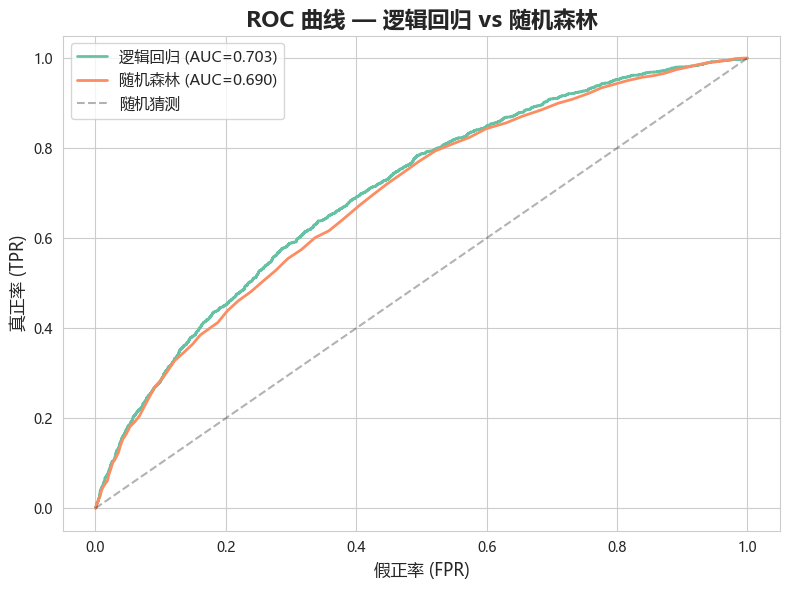

In [29]:
# ROC 曲线对比

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, label=f"逻辑回归 (AUC={roc_auc_score(y_test, y_prob_lr):.3f})", linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f"随机森林 (AUC={roc_auc_score(y_test, y_prob_rf):.3f})", linewidth=2)
ax.plot([0,1], [0,1], "k--", alpha=0.3, label="随机猜测")
ax.set_xlabel("假正率 (FPR)", fontsize=12)
ax.set_ylabel("真正率 (TPR)", fontsize=12)
ax.set_title("ROC 曲线 — 逻辑回归 vs 随机森林", fontsize=16, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig6_roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

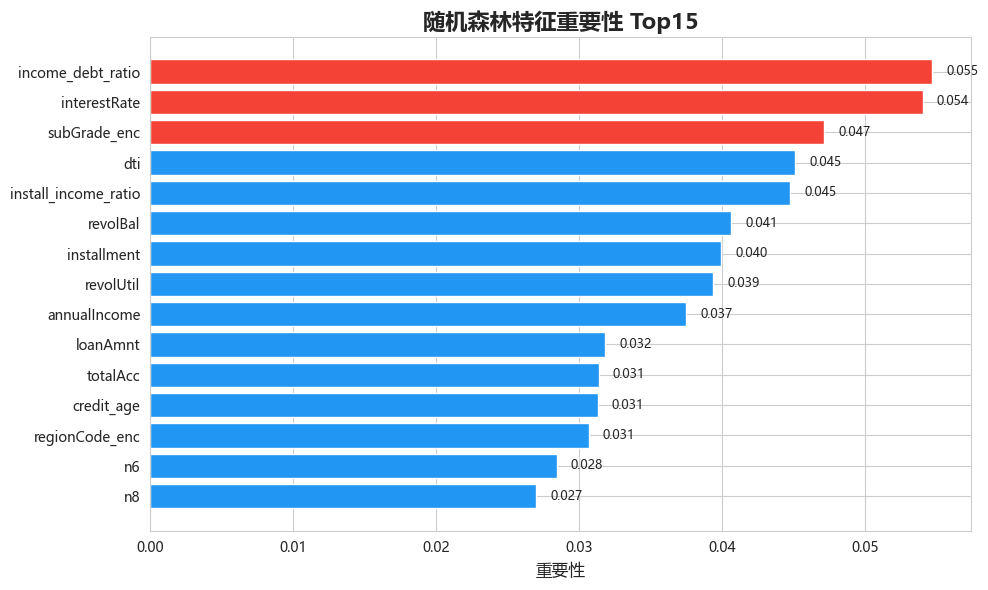

Top 15 重要特征:
                  特征      重要性
   income_debt_ratio 0.054667
        interestRate 0.053999
        subGrade_enc 0.047135
                 dti 0.045092
install_income_ratio 0.044743
            revolBal 0.040615
         installment 0.039931
           revolUtil 0.039325
        annualIncome 0.037444
            loanAmnt 0.031818
            totalAcc 0.031348
          credit_age 0.031282
      regionCode_enc 0.030653
                  n6 0.028411
                  n8 0.026965


In [30]:
# 特征重要性 Top15

importance = pd.DataFrame({"特征": X_train.columns, "重要性": rf.feature_importances_})
importance = importance.sort_values("重要性", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#F44336" if i < 3 else "#2196F3" for i in range(len(importance))]
ax.barh(range(len(importance)), importance["重要性"].values[::-1], color=colors[::-1])
ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance["特征"].values[::-1])
ax.set_xlabel("重要性", fontsize=12)
ax.set_title("随机森林特征重要性 Top15", fontsize=16, fontweight="bold")
for i, v in enumerate(importance["重要性"].values[::-1]):
    ax.text(v+0.001, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig7_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Top 15 重要特征:")
print(importance.to_string(index=False))

In [31]:
# 模型对比总结

# 逻辑回归最优阈值
y_pred_lr_best = (y_prob_lr >= lr_best_t).astype(int)
lr_acc = accuracy_score(y_test, y_pred_lr_best)
lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_prec = precision_score(y_test, y_pred_lr_best)
lr_rec = recall_score(y_test, y_pred_lr_best)
lr_f1 = f1_score(y_test, y_pred_lr_best)

# 随机森林最优阈值（使用 threshold-1 扫描结果，不硬编码）
y_pred_rf_best = (y_prob_rf >= best_threshold).astype(int)
rf_acc = accuracy_score(y_test, y_pred_rf_best)
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_prec = precision_score(y_test, y_pred_rf_best)
rf_rec = recall_score(y_test, y_pred_rf_best)
rf_f1 = f1_score(y_test, y_pred_rf_best)

comparison = pd.DataFrame({
    "模型": [f"逻辑回归 (阈值{lr_best_t})", f"随机森林 (阈值{best_threshold})"],
    "准确率": [lr_acc, rf_acc],
    "AUC": [lr_auc, rf_auc],
    "精确率": [lr_prec, rf_prec],
    "召回率": [lr_rec, rf_rec],
    "F1-score": [lr_f1, rf_f1]
})

print("模型对比总结")
print("=" * 70)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
print("结论: 逻辑回归以更高 AUC 和可解释性胜出；随机森林在最优阈值下召回率更高但精确率偏低。")

模型对比总结
          模型    准确率    AUC    精确率    召回率  F1-score
逻辑回归 (阈值0.5) 0.6572 0.7027 0.3168 0.6288    0.4213
随机森林 (阈值0.3) 0.5853 0.6902 0.2849 0.7217    0.4086

结论: 逻辑回归以更高 AUC 和可解释性胜出；随机森林在最优阈值下召回率更高但精确率偏低。


In [32]:
# 风险-价值四象限矩阵

# ── 风险评分：逻辑回归预测违约概率 ──────────────────
risk_score = lr.predict_proba(X_model)[:, 1]

# ── 价值评分 = 收入潜力 − 负债负担 ──────────────────
# 收入高 → 未来借贷空间大 → 客户潜力价值高
# 贷款/收入比高 → 债务负担重 → 剩余借贷空间小 → 价值低
from sklearn.preprocessing import StandardScaler as SS

# 贷款收入比（截断极端值）
df["loan_income_ratio"] = df["loanAmnt"] / df["annualIncome"]
df["loan_income_ratio"] = df["loan_income_ratio"].clip(upper=5.0)

# Z-score 标准化
v_scaler = SS()
income_z = v_scaler.fit_transform(df[["annualIncome"]]).flatten()
ratio_z = v_scaler.fit_transform(df[["loan_income_ratio"]]).flatten()

# 价值评分
value_score = income_z - ratio_z

print(f"风险评分: {risk_score.min():.3f} ~ {risk_score.max():.3f}, 中位数: {np.median(risk_score):.3f}")
print(f"价值评分: {value_score.min():.3f} ~ {value_score.max():.3f}, 中位数: {np.median(value_score):.3f}")
print(f"风险 vs 价值相关系数: {np.corrcoef(risk_score, value_score)[0,1]:.4f}")

风险评分: 0.000 ~ 0.986, 中位数: 0.445
价值评分: -34.156 ~ 5.591, 中位数: -0.077
风险 vs 价值相关系数: -0.4090


In [33]:
# ── 四象限分类（中位数二分） ─────────────────────────
risk_median = np.median(risk_score)
value_median = np.median(value_score)

quadrant = []
for r, v in zip(risk_score, value_score):
    if r < risk_median and v >= value_median:
        quadrant.append("明星客户")      # 低风险 + 高价值
    elif r < risk_median and v < value_median:
        quadrant.append("潜力客户")      # 低风险 + 低价值
    elif r >= risk_median and v >= value_median:
        quadrant.append("挽留客户")      # 高风险 + 高价值
    else:
        quadrant.append("拒绝客户")      # 高风险 + 低价值

quad_counts = pd.Series(quadrant).value_counts()
print("四象限客户分布:")
for label, cnt in quad_counts.items():
    print(f"  {label}: {cnt} ({cnt/len(quadrant)*100:.1f}%)")

四象限客户分布:
  明星客户: 9950 (33.2%)
  拒绝客户: 9950 (33.2%)
  潜力客户: 5050 (16.8%)
  挽留客户: 5050 (16.8%)


价值评分 < -20 截断: 10 条 (0.03%)


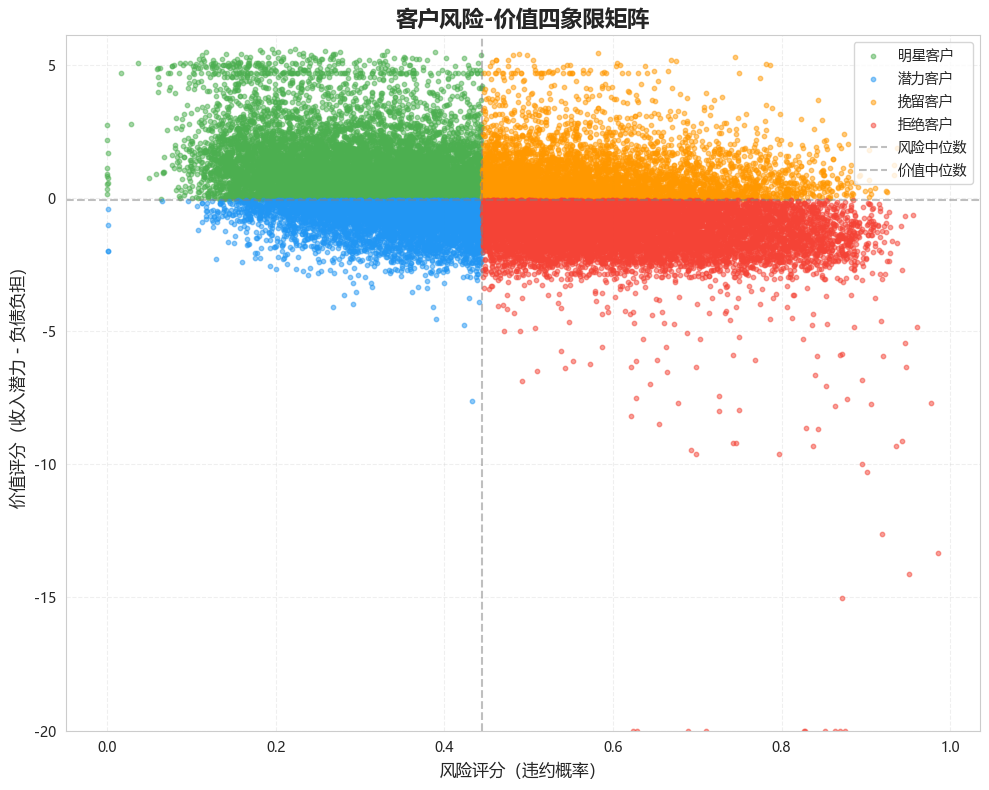

In [34]:
# 散点图（价值 < -20 截断，加网格）
value_plot = np.clip(value_score, -20, None)
n_clipped = (value_score < -20).sum()
print(f"价值评分 < -20 截断: {n_clipped} 条 ({n_clipped/len(value_score)*100:.2f}%)")

color_map = {"明星客户": "#4CAF50", "潜力客户": "#2196F3", "挽留客户": "#FF9800", "拒绝客户": "#F44336"}
fig, ax = plt.subplots(figsize=(10, 8))
for q in color_map:
    mask = [x == q for x in quadrant]
    ax.scatter(risk_score[mask], value_plot[mask], c=color_map[q], label=q, alpha=0.5, s=10)
ax.axvline(risk_median, color="gray", linestyle="--", alpha=0.5, label="风险中位数")
ax.axhline(np.median(value_plot), color="gray", linestyle="--", alpha=0.5, label="价值中位数")
ax.set_xlabel("风险评分（违约概率）", fontsize=12)
ax.set_ylabel("价值评分（收入潜力 - 负债负担）", fontsize=12)
ax.set_title("客户风险-价值四象限矩阵", fontsize=16, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_ylim(-20, value_plot.max() + 0.5)
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig8_quadrant.png"), dpi=150, bbox_inches="tight")
plt.show()

收入五等分 - 高收入 -> 低风险 -> 高价值:
                  客户数        平均收入  平均贷款收入比    违约率  平均风险评分  平均价值评分
income_quintile                                                  
Q1(最低收入)         6173   32692.452    0.271  0.227   0.515  -1.372
Q2               5975   49990.559    0.236  0.217   0.486  -0.723
Q3               5886   65233.497    0.219  0.209   0.468  -0.245
Q4               6338   86140.883    0.196  0.183   0.437   0.403
Q5(最高收入)         5628  143836.377    0.151  0.154   0.379   2.076


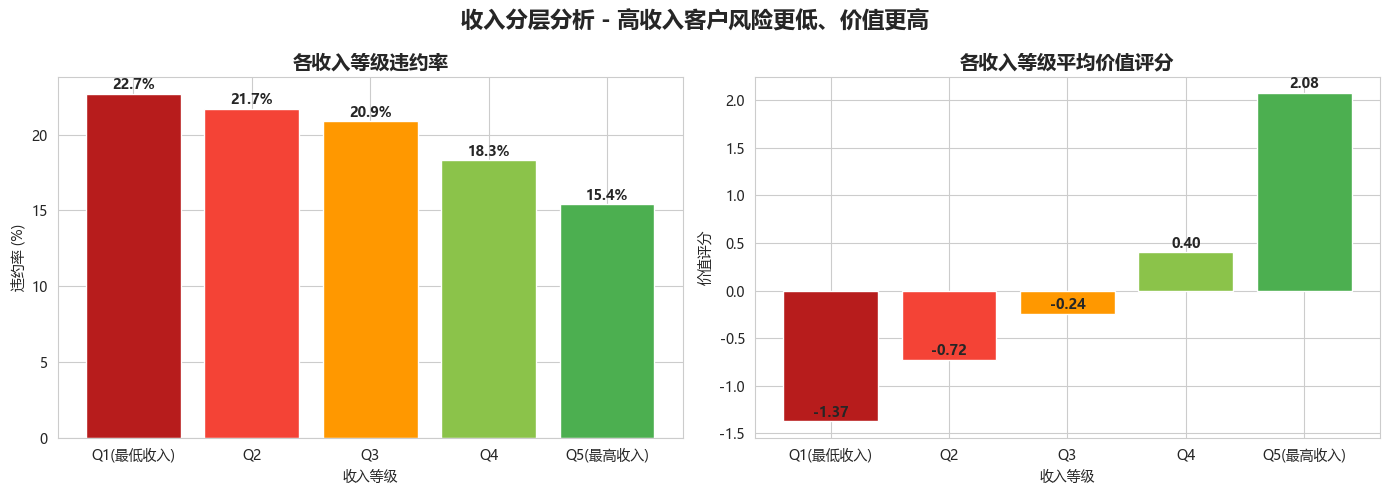

In [35]:
# 收入五等分验证
df["income_quintile"] = pd.qcut(
    df["annualIncome"], q=5,
    labels=["Q1(最低收入)", "Q2", "Q3", "Q4", "Q5(最高收入)"]
)
df["risk_score"] = risk_score
df["value_score"] = value_score

income_tier = df.groupby("income_quintile").agg(
    客户数=("annualIncome", "count"),
    平均收入=("annualIncome", "mean"),
    平均贷款收入比=("loan_income_ratio", "mean"),
    违约率=("isDefault", "mean"),
    平均风险评分=("risk_score", "mean"),
    平均价值评分=("value_score", "mean")
).round(3)

print("收入五等分 - 高收入 -> 低风险 -> 高价值:")
print(income_tier.to_string())

# 收入分层可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tier_colors = ["#B71C1C", "#F44336", "#FF9800", "#8BC34A", "#4CAF50"]

axes[0].bar(income_tier.index, income_tier["违约率"] * 100, color=tier_colors)
for i, v in enumerate(income_tier["违约率"] * 100):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")
axes[0].set_title("各收入等级违约率", fontsize=14, fontweight="bold")
axes[0].set_xlabel("收入等级"); axes[0].set_ylabel("违约率 (%)")

axes[1].bar(income_tier.index, income_tier["平均价值评分"], color=tier_colors)
for i, v in enumerate(income_tier["平均价值评分"]):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")
axes[1].set_title("各收入等级平均价值评分", fontsize=14, fontweight="bold")
axes[1].set_xlabel("收入等级"); axes[1].set_ylabel("价值评分")

fig.suptitle("收入分层分析 - 高收入客户风险更低、价值更高", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig10_income_tier.png"), dpi=150, bbox_inches="tight")
plt.show()

## 阶段二完成

| 任务 | 状态 |
|:---|---:|
| 训测划分 | done |
| 逻辑回归 | done |
| 随机森林 | done |
| ROC曲线对比 | done |
| 特征重要性 | done |
| 四象限矩阵 | done |

**产出**: `figures/fig6~8.png`

**下一步**: 阶段三 — Tableau 看板制作